In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.competition_download('playground-series-s6e5')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e5


In [3]:
df_train = pd.read_csv(f'{path}/train.csv')
df_test = pd.read_csv(f'{path}/test.csv')
df = pd.concat([df_train, df_test],sort=False)
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 627305 entries, 0 to 188164
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      627305 non-null  int64  
 1   Driver                  627305 non-null  str    
 2   Compound                627305 non-null  str    
 3   Race                    627305 non-null  str    
 4   Year                    627305 non-null  int64  
 5   PitStop                 627305 non-null  int64  
 6   LapNumber               627305 non-null  int64  
 7   Stint                   627305 non-null  int64  
 8   TyreLife                627305 non-null  float64
 9   Position                627305 non-null  int64  
 10  LapTime (s)             627305 non-null  float64
 11  LapTime_Delta           627305 non-null  float64
 12  Cumulative_Degradation  627305 non-null  float64
 13  RaceProgress            627305 non-null  float64
 14  Position_Change         627305 non-n

<Axes: xlabel='RaceProgress', ylabel='Position_Change'>

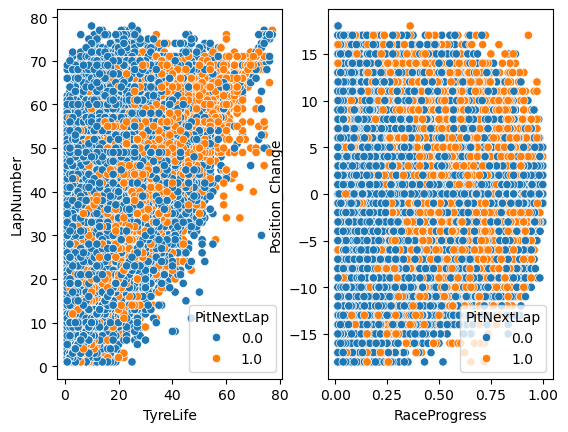

In [5]:
fig, axes = plt.subplots(1,2)
sns.scatterplot(df,x='TyreLife', y='LapNumber', hue='PitNextLap',ax=axes[0])
sns.scatterplot(df,x='RaceProgress', y='Position_Change', hue='PitNextLap',ax=axes[1])

<Axes: >

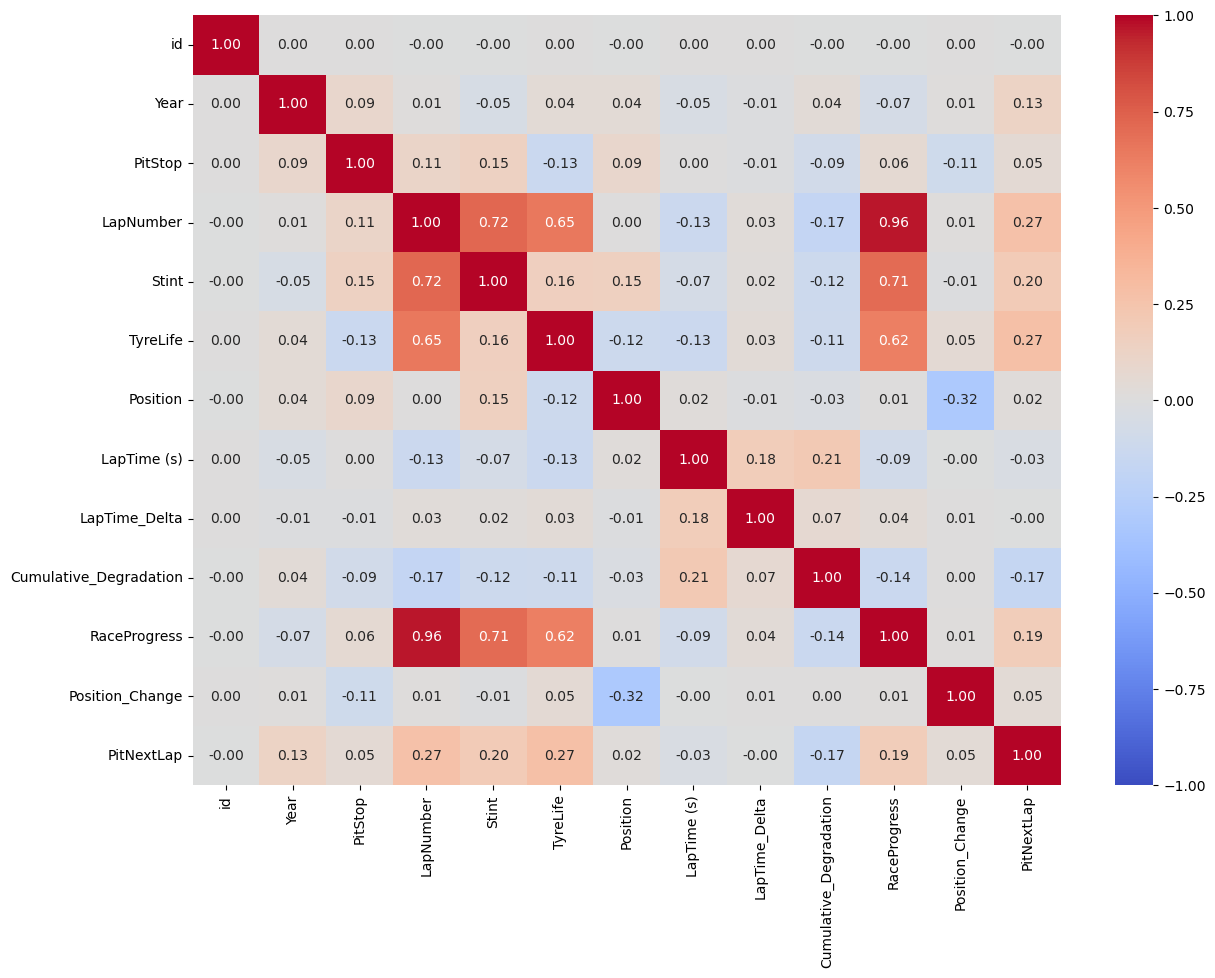

In [6]:
features_numericas = df.select_dtypes(include=['number']).columns

corr_matrix = df[features_numericas].corr()

plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    annot=True,
    cmap='coolwarm'
)

In [7]:
corr_matrix['PitNextLap'].sort_values(ascending=False)

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
id                       -0.000097
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64

In [8]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,627305.000000,439140.000000
mean,313652.000000,2023.525013,0.136162,23.089194,1.787650,14.158949,9.622600,90.960173,-3.712377,-25.760073,0.337371,0.103119,0.198982
std,181087.499645,1.025066,0.342961,16.971487,0.949778,9.816788,5.277182,20.103578,42.898465,54.812708,0.253313,4.010915,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,156826.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.624000,-8.879000,-46.642000,0.128571,-1.000000,0.000000
50%,313652.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.510000,-0.293000,-21.005000,0.269231,0.000000,0.000000
75%,470478.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.477000,0.118000,-6.195000,0.513158,2.000000,0.000000
max,627304.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2433.472000,2412.026000,1.000000,18.000000,1.000000


In [9]:
df.isnull().sum()

id                             0
Driver                         0
Compound                       0
Race                           0
Year                           0
PitStop                        0
LapNumber                      0
Stint                          0
TyreLife                       0
Position                       0
LapTime (s)                    0
LapTime_Delta                  0
Cumulative_Degradation         0
RaceProgress                   0
Position_Change                0
PitNextLap                188165
dtype: int64

In [10]:
for col in df.select_dtypes(include=['str']).columns:
    print(f'{col} - {df[col].nunique()}')

Driver - 887
Compound - 5
Race - 26


In [11]:
for col in df.select_dtypes(include=['number']).columns:
    print(f'{col} - {df[col].nunique()}')

id - 627305
Year - 4
PitStop - 2
LapNumber - 78
Stint - 8
TyreLife - 78
Position - 20
LapTime (s) - 40565
LapTime_Delta - 65243
Cumulative_Degradation - 172744
RaceProgress - 2097
Position_Change - 37
PitNextLap - 2


In [12]:
ids_submissao = df_test['id'].copy()

cols_to_scale = ['LapNumber', 'Stint', 'TyreLife', 'Cumulative_Degradation','Position_Change','LapTime_Delta','LapTime (s)']
cols_to_oneHot = ['Compound','Race']

cols_to_remove = ['id','Driver']

df = df.drop(columns=cols_to_remove)

preprocessing = ColumnTransformer(
    transformers=[
        ('num',RobustScaler(),cols_to_scale),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cols_to_oneHot)
    ],
    remainder='passthrough'
)

df_processed = preprocessing.fit_transform(df)

colunas_novas = preprocessing.get_feature_names_out()

df = pd.DataFrame(data=df_processed, columns=colunas_novas)

In [13]:
df.head()

,num__LapNumber,num__Stint,num__TyreLife,num__Cumulative_Degradation,num__Position_Change,num__LapTime_Delta,num__LapTime (s),cat__Compound_HARD,cat__Compound_INTERMEDIATE,cat__Compound_MEDIUM,...,cat__Race_Saudi Arabian Grand Prix,cat__Race_Singapore Grand Prix,cat__Race_Spanish Grand Prix,cat__Race_São Paulo Grand Prix,cat__Race_United States Grand Prix,remainder__Year,remainder__PitStop,remainder__Position,remainder__RaceProgress,remainder__PitNextLap
0,1.148148,0.0,1.928571,1.038989,1.666667,-0.808158,-0.758153,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2022.0,0.0,8.0,0.714286,1.0
1,0.296296,0.0,-0.357143,-4.999184,-1.000000,-3.592753,-0.972371,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2025.0,1.0,4.0,0.346154,0.0
2,1.481481,1.0,0.714286,-1.966129,1.000000,-0.805491,-1.234151,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2022.0,0.0,13.0,0.819444,1.0
3,-0.629630,-1.0,-0.714286,0.338245,0.000000,-0.781483,0.242919,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,2023.0,0.0,7.0,0.076923,0.0
4,0.259259,1.0,-0.428571,0.169753,1.000000,1.029010,1.095566,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2022.0,1.0,2.0,0.361111,0.0


In [14]:
training_data = df[:df_train.shape[0]]
testing_data = df[df_train.shape[0]:]

In [15]:
testing_data = testing_data.drop(columns='remainder__PitNextLap')

In [16]:
X = training_data.drop(columns='remainder__PitNextLap')
y = training_data['remainder__PitNextLap']

In [17]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    shuffle=True, 
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.25, 
    random_state=42, 
    shuffle=True, 
    stratify=y_train_val 
)

len(X_train),len(X_test), len(X_val)

(263484, 87828, 87828)

In [23]:
best_model = XGBClassifier(
    subsample= 1.0, 
    scale_pos_weight= 1.0,
    reg_lambda= 1.0, 
    reg_alpha= 0,
    n_estimators= 600, 
    min_child_weight=5,
    max_depth= 10,
    learning_rate = 0.03, 
    gamma = 0, 
    colsample_bytree = 0.5,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)



,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [24]:
proba_test = best_model.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, proba_test)
print("AUC no teste:", auc_test)

AUC no teste: 0.9494650869319179


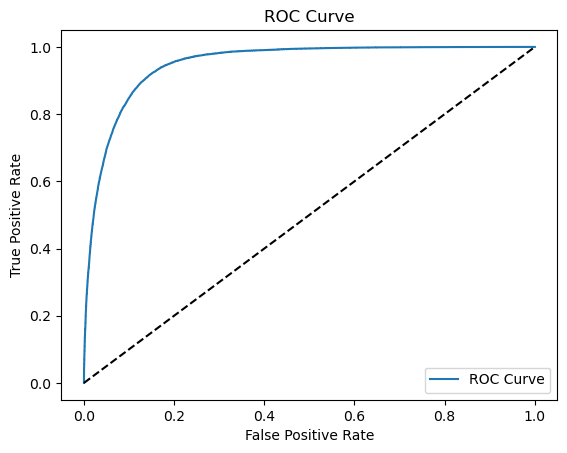

In [25]:
fpr, tpr ,thresholds = roc_curve(y_test,proba_test)
plt.plot(fpr, tpr, label=f'ROC Curve')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [26]:
preds_finais = best_model.predict_proba(testing_data)[:, 1]

submission = pd.DataFrame({
    'id': ids_submissao,
    'PitNextLap': preds_finais
})

submission.to_csv('submission.csv', index=False)

submission.head()

,id,PitNextLap
0,439140,0.004443
1,439141,0.003754
2,439142,0.003900
3,439143,0.157486
4,439144,0.873815


In [28]:
import joblib

joblib.dump(best_model, 'xgboostClassifier.pkl')

['xgboostClassifier.pkl']